In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)
df.head()

Saving Day14_Food_Delivery_Visualization_Dataset.csv to Day14_Food_Delivery_Visualization_Dataset.csv


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Shape: (360, 16)

Columns:
['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine', 'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Ord

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:
Order_Batch_ID             0
Date                       0
Month                      0
Day                        0
City                       0
Cuisine                    0
Order_Channel              0
Weather                    0
Orders                     0
Average_Order_Value        0
Revenue                    0
Marketing_Spend            0
Discounts                  0
Avg_Delivery_Minutes       0
Customer_Rating            0
Repeat_Customer_Percent    0
dtype: int64

Duplicate Records: 0


In [5]:
df.describe()

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
std,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472
min,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
143,FD0144,2025-01-02,January,Thursday,Mumbai,Biryani,Website,Rainy,153,417.10,60737.12,23547.30,3265.59,39.1,4.14,36.8
274,FD0275,2025-01-03,January,Friday,Kochi,Chinese,App,Hot,116,380.72,39270.56,18855.32,3746.66,30.5,4.55,44.7
254,FD0255,2025-01-03,January,Friday,Delhi,Biryani,Website,Clear,142,439.59,70923.09,16235.11,4103.07,36.7,4.32,32.0
35,FD0036,2025-01-04,January,Saturday,Kochi,Chinese,App,Hot,116,360.82,44866.11,15073.06,3266.97,27.2,4.57,43.9
262,FD0263,2025-01-05,January,Sunday,Kochi,North Indian,Website,Cloudy,117,419.96,48166.96,17316.98,4452.69,31.6,4.57,42.1


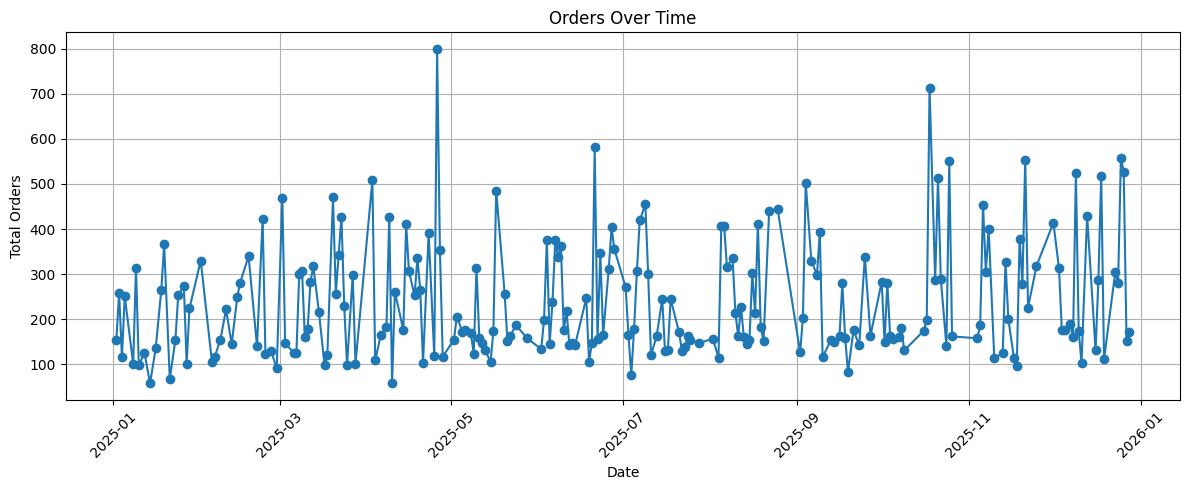

In [7]:
daily_orders = df.groupby("Date")["Orders"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_orders.index, daily_orders.values, marker="o")
plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

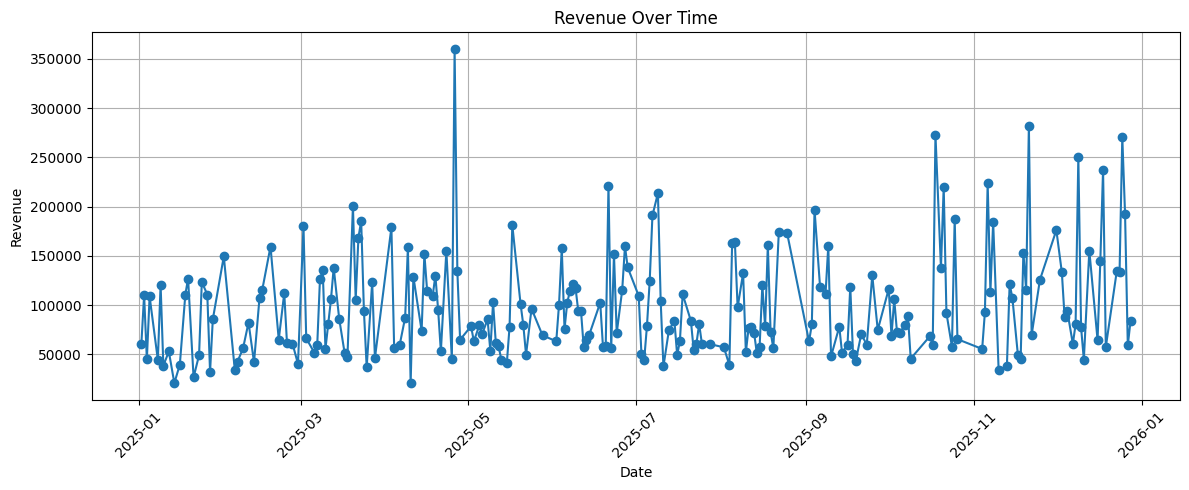

In [8]:
daily_revenue = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_revenue.index, daily_revenue.values, marker="o")
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

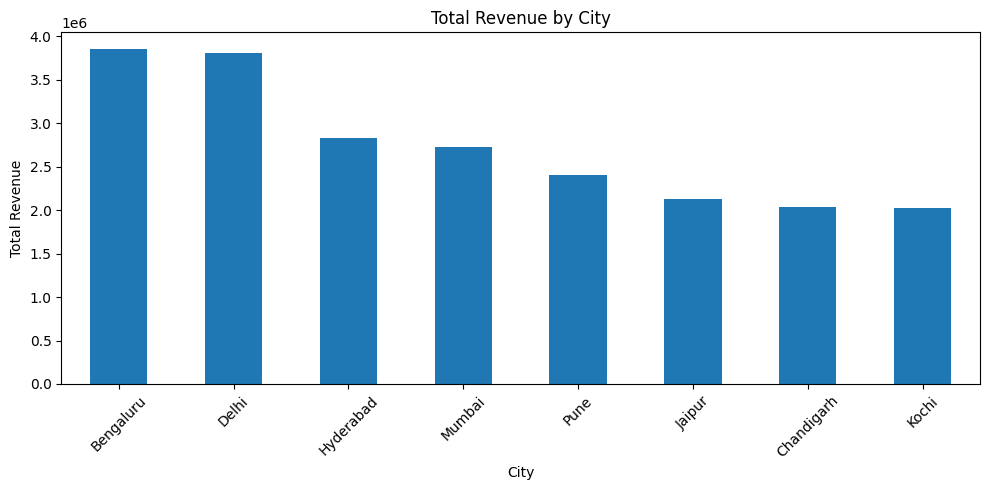

In [9]:
city_revenue = df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
city_revenue.plot(kind="bar")
plt.title("Total Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

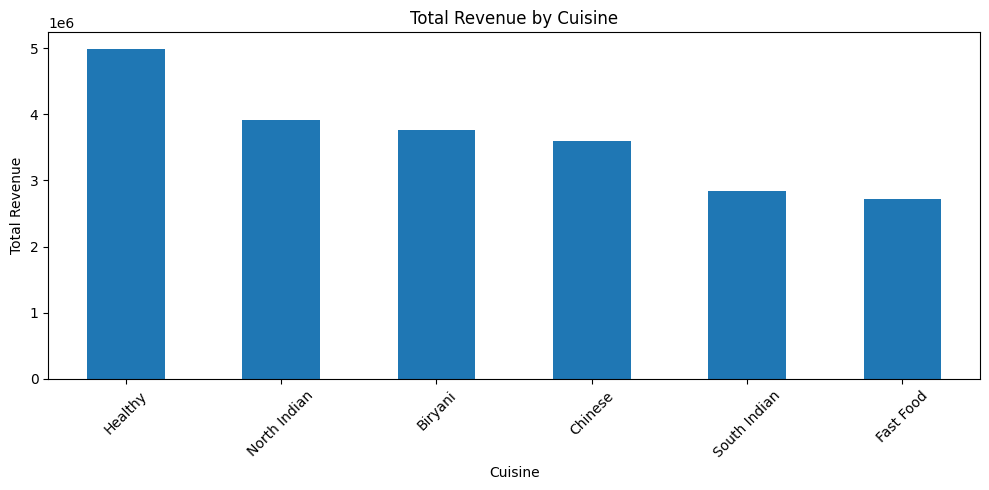

In [10]:
cuisine_revenue = df.groupby("Cuisine")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
cuisine_revenue.plot(kind="bar")
plt.title("Total Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

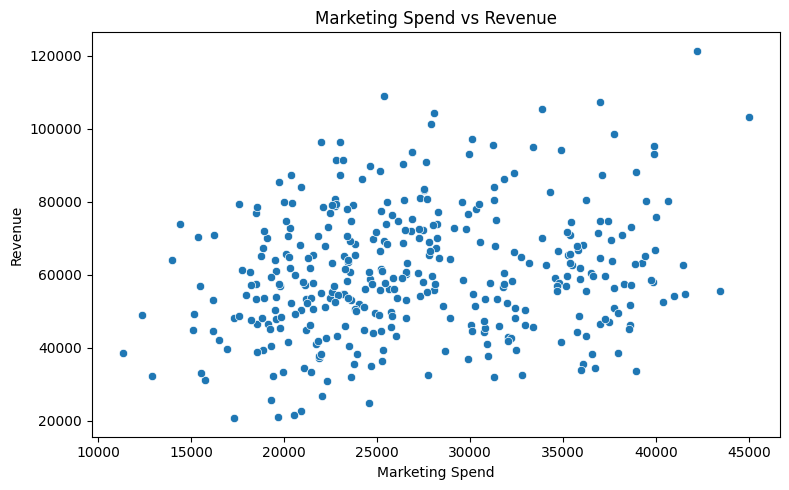

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue"
)

plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

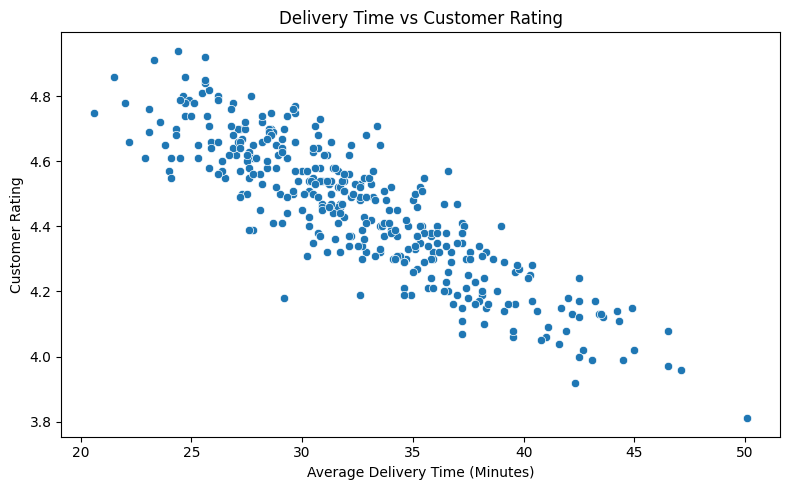

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating"
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

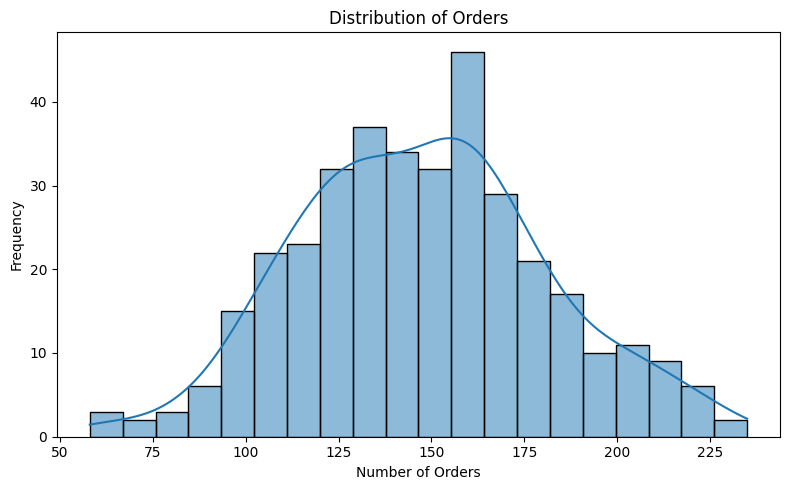

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Orders",
    bins=20,
    kde=True
)

plt.title("Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

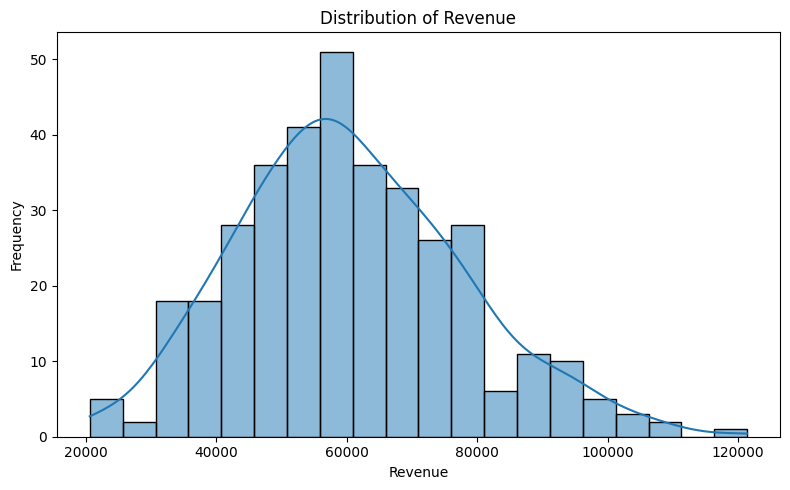

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Revenue",
    bins=20,
    kde=True
)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

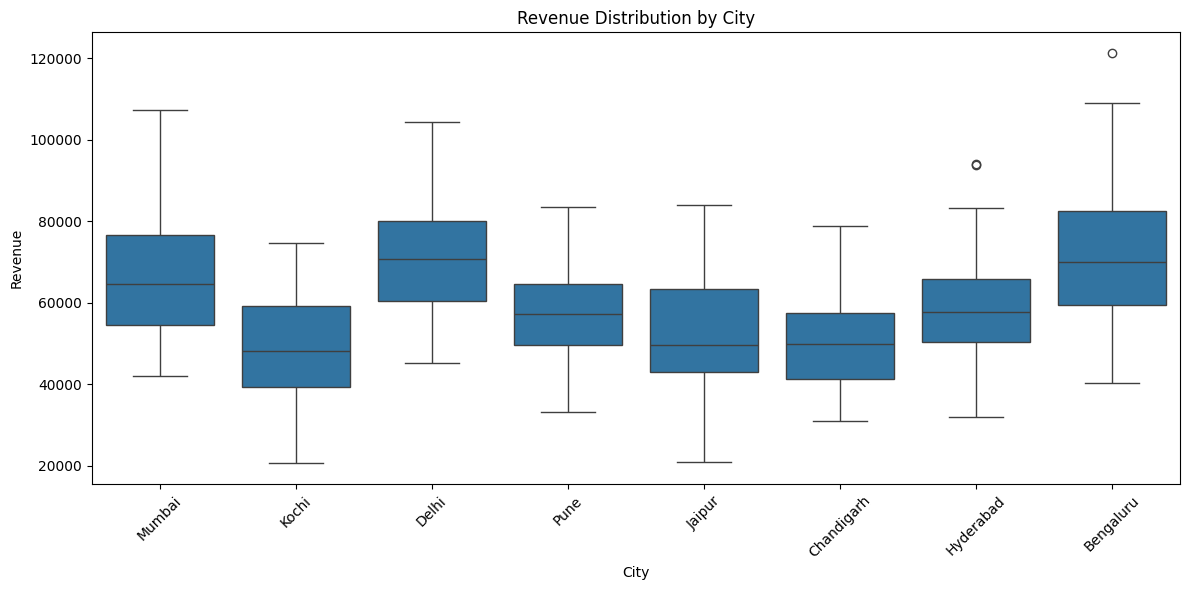

In [15]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="City",
    y="Revenue"
)

plt.title("Revenue Distribution by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

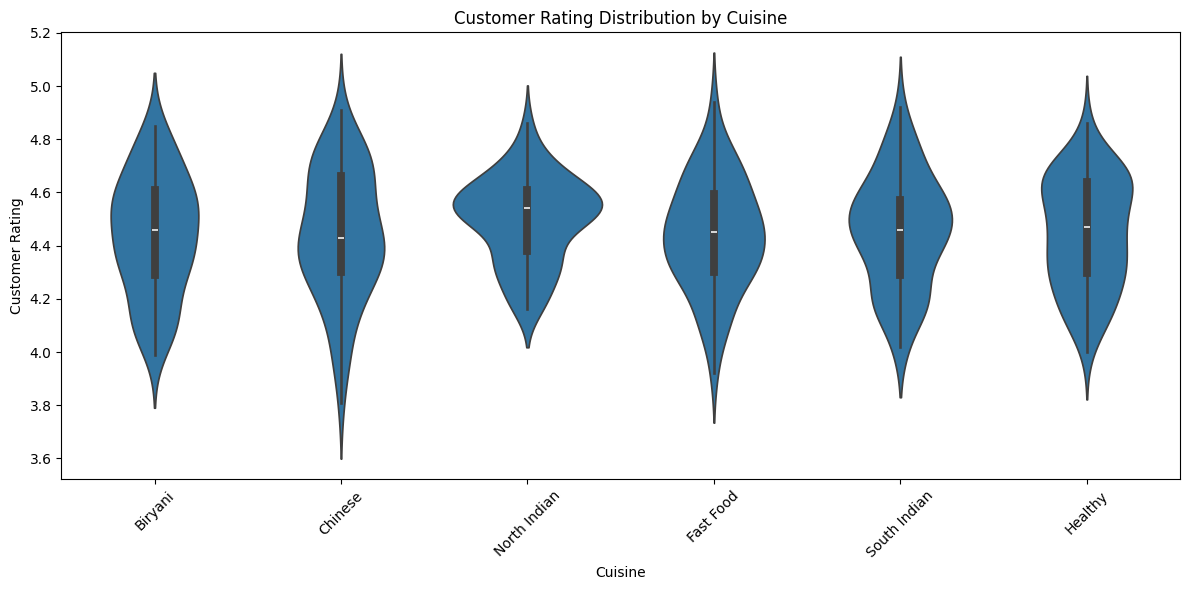

In [16]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="Cuisine",
    y="Customer_Rating"
)

plt.title("Customer Rating Distribution by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Customer Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

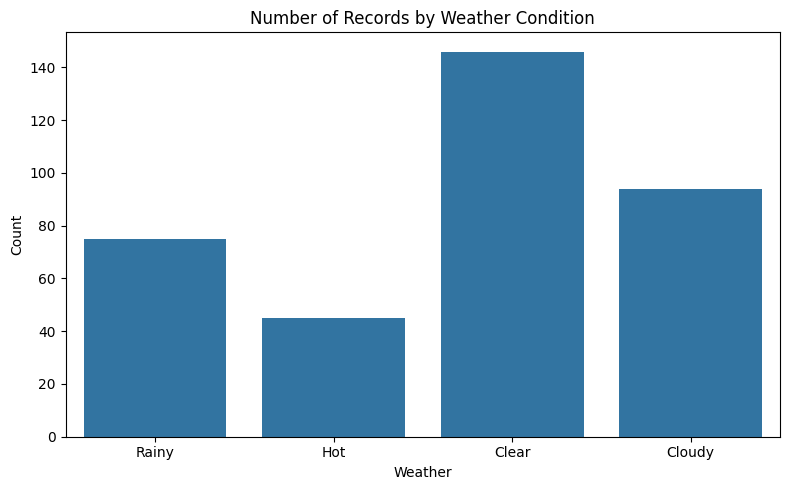

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Weather"
)

plt.title("Number of Records by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

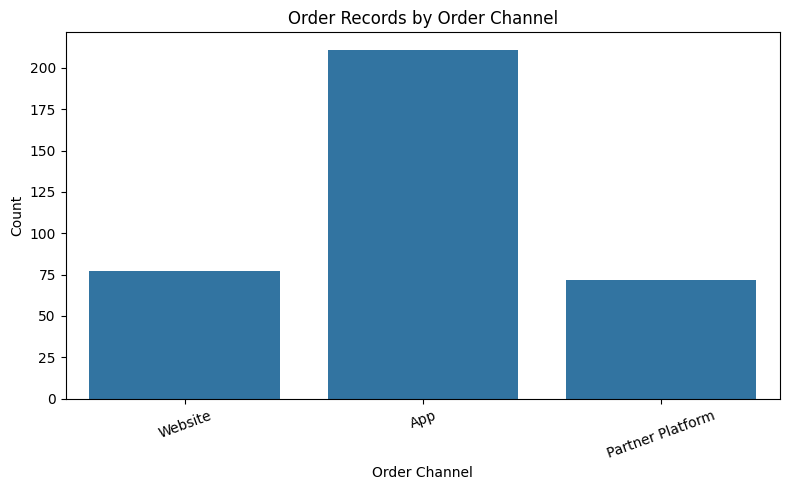

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Order_Channel"
)

plt.title("Order Records by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

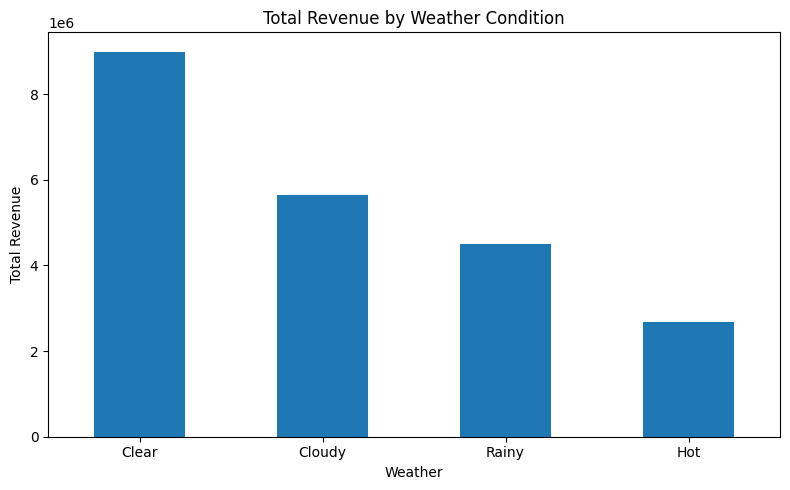

In [19]:
weather_revenue = df.groupby("Weather")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
weather_revenue.plot(kind="bar")
plt.title("Total Revenue by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

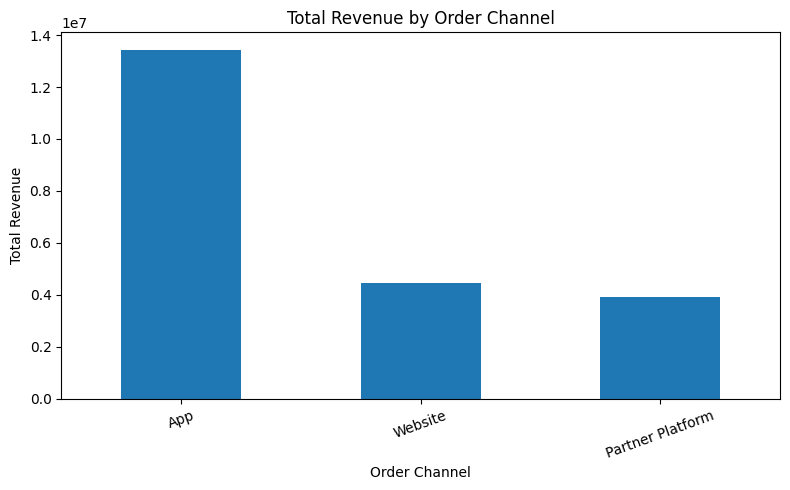

In [20]:
channel_revenue = df.groupby("Order_Channel")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
channel_revenue.plot(kind="bar")
plt.title("Total Revenue by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Total Revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

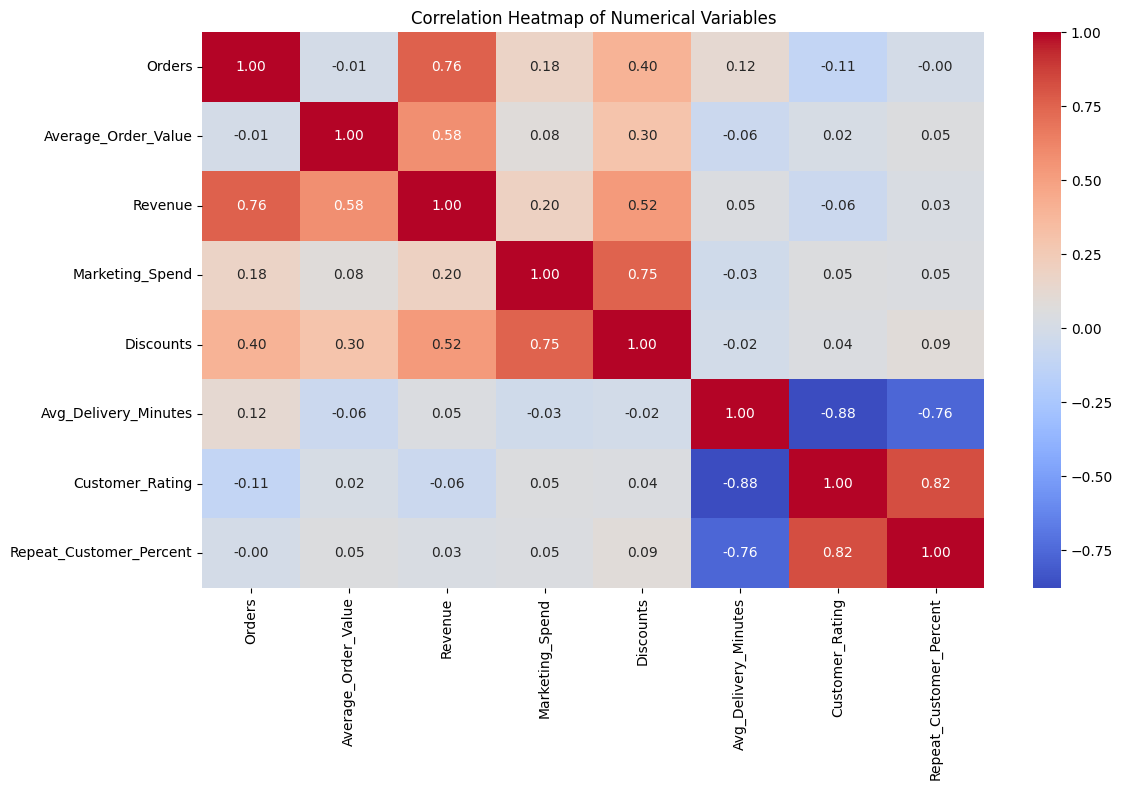

In [21]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

### Key Observations

1. **Bengaluru generated the highest total revenue among the cities**, with revenue of approximately **₹38,51,958.65**.

2. **Healthy cuisine generated the highest total revenue**, contributing approximately **₹49,88,656.66**.

3. The **App was the highest-revenue order channel**, generating approximately **₹1,34,35,579.94** in total revenue.

4. **Clear weather recorded the highest total revenue**, with approximately **₹89,94,356.98**, indicating strong business activity during clear weather conditions.

5. The dataset recorded an **average of 147.65 orders** per order batch, while the **average revenue was ₹60,591.11**.

6. **Marketing Spend and Revenue had a weak positive correlation of 0.20**, suggesting that marketing expenditure has only a limited linear relationship with revenue in this dataset.

7. **Delivery Time and Customer Rating showed a strong negative correlation of -0.88**, indicating that longer delivery times are strongly associated with lower customer ratings.

8. **North Indian cuisine had the highest average customer rating**, with an average rating of approximately **4.50 out of 5**, indicating high customer satisfaction for this cuisine.
